качаем библиотеки

In [30]:
import pandas as pd
import numpy as np

import statistics
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import t

#### Проект
Наша кампания ранне имела всего один продукт, он был запущен давно. У нас есть записи сколько выручки нам приносил этот продукт за каждый день его работы. Пару месяцев назад кампания запустила второй продукт, и так же ежедневно фиксировала выручку которую он нам приносил. Данные по выручкам сохранены ниже в переменных product1 и product2.<br>
Наша задача сделать полный анализ на основе всего лишь этих двух списках.

In [12]:
### для загрузки данных
with open('project.txt') as fp:
    for i, line in enumerate(fp):
        if i == 0:
            product1 = [int(i) for i in line.split(' ')]
        if i == 1:
            product2 = [int(i) for i in line.split(' ')]

fp.close()

**Задача 1**<br>
подсчитайте среднее арифметическое (mean), медиану и моду для обоих списков: product1 и product2

In [21]:
print(np.mean(product1))
print(np.median(product1))
print(statistics.mode(product1))

199.103
198.5
186


In [22]:
print(np.mean(product2))
print(np.median(product2))
print(statistics.mode(product2))

193.5
194.5
227


Какая из трех метрик будет наименее показательной, и почему?<br>
На основе оставшихся двух метрик какой продукт в среднем приносит больше выручки?

**Задача 2**<br>
подсчитайте стандартное отклонение и скажите оценка какого продукта является более точной?

In [26]:
print(np.std(product1))
print(np.std(product2))

28.793964489107783
29.589018233121557


**Задача 3**<br>
Нарисуйте распределение вероятности выручки для продукта1 и для продукта2.<br>
Можете использовать гистограмму или kdeplot

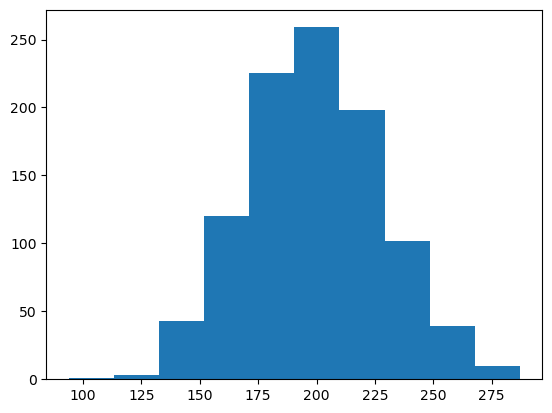

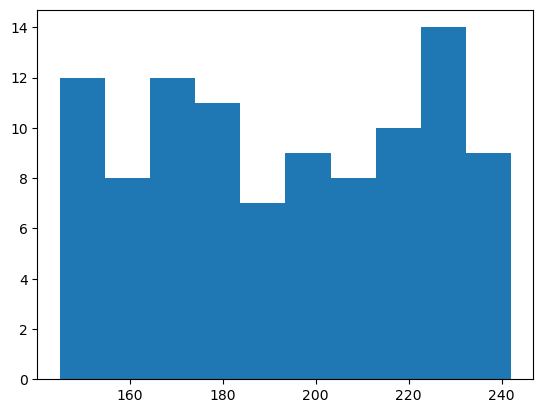

In [28]:
plt.hist(product1)
plt.show()

plt.hist(product2)
plt.show()

**Задача 4**<br>
Посчитайте размах выручки для продукта1 и для продукта2<br>
Сходится ли разница в размахах и разница в стандартных отклонениях, какая может быть причина?

In [32]:
product1 = pd.Series(product1)

In [34]:
product2 = pd.Series(product2)

In [40]:
range1 = product1.max() - product1.min()
print(range1)

193


In [42]:
range2 = product2.max() - product2.min()
print(range2)

97


**Задача 5**<br>
Посчитайте межквартильный разммах IQR для продукта1 и продукта2<br>
Теперь убрав выбросы что мы можем сказать о разбросе данных?

In [36]:
Q1 = product1.quantile(0.25)
Q3 = product1.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

38.25


In [37]:
Q1 = product2.quantile(0.25)
Q3 = product2.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

51.0


**Задача 6**<br>
Нарисуйте box-plot для продукта1 и с рисунка скажите при каких значениях начинаются выбросы

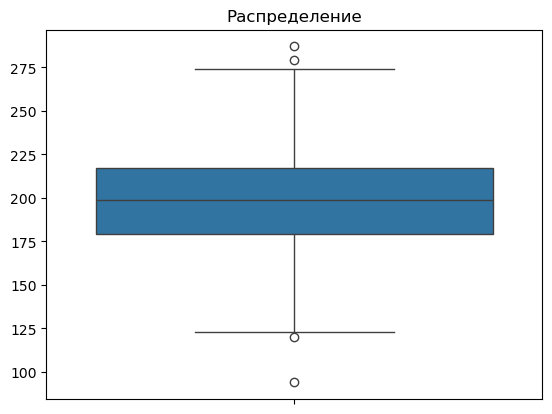

In [44]:
plt.figure()
sns.boxplot(product1)
plt.title("Распределение")
plt.show()

**Задача 7**<br>
Нарисуйте QQ plot выручки для обоих продуктов<br>
Какое из распределений является нормальным?

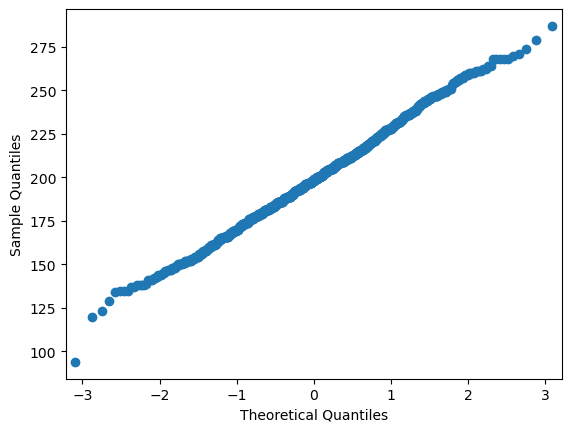

In [46]:
sm.qqplot(product1)
plt.show()

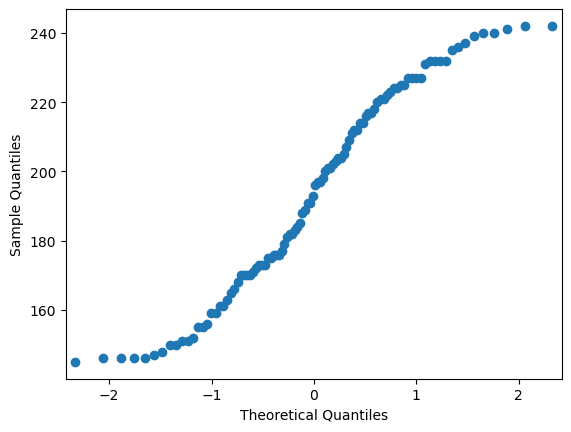

In [47]:
sm.qqplot(product2)
plt.show()

Каких значений много или наоборот не достает в продукте2 чтобы значения стали нормально распределенными?

**Задача 8**<br>
И так мы знаем что выручка продукта1 является нормально распредленной, переведите все значения в стандартное нормальное распределение используя текущие mean и std<br>
создайте новую переменнуя и запишите новые значения туда

In [48]:
me = product1.mean()
st = product1.std()

product3 = (product1 - me)/ st

Нарисуйте kdeplot нового стандартного распределения

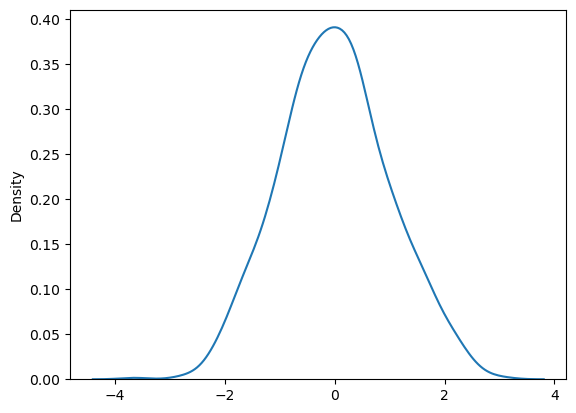

In [49]:
sns.kdeplot(product3)
plt.show()

**Задача 9**<br>
Подсчитайте точку слева от которой будет 1% всей вероятности распределения

In [50]:
x = norm.ppf(0.01)
y = me + x * st
print(x)
print(y)

-2.3263478740408408
132.08470439627652


Первое значение в списке product1 равно 94. Когда мы преобразуем список в стандартное нормальное распределение, 94 преобразуется в -3.65<br>
Что нам говорит это число, особенно при сравнении с точкой которую мы только что подсчитали?

**Задача 10**<br>
Продукт2 новый, но уже достаточно стабилизирвался за эти месяцы. Мы хотим знать сколько он будет в среднем нам приносить ежедневно выручки и в будущем.<br>
Дайте точечную оценку средней выручке продукта2

In [52]:
norm_dist_std = np.std(product2, ddof=1) / np.sqrt(len(product2))
mean = np.mean(product2)
print(norm_dist_std, mean)

2.973808224068148 193.5


Подсчитайте 95% доверительный интервал

In [53]:
norm_dist_std = np.std(product2, ddof=1) / np.sqrt(len(product2))
mean = np.mean(product2)
z = norm.ppf(0.95)
c = (mean - z* norm_dist_std, mean + z* norm_dist_std)
print(norm_dist_std, mean)
print(c)

2.973808224068148 193.5
(np.float64(188.60852075678338), np.float64(198.39147924321662))


**Задача11**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 выше чем 197.5

In [54]:
mean1, s1, n1 = np.mean(product1), np.std(product1, ddof=1), len(product1)
t_stat = (mean1 - 197.5) / (s1/np.sqrt(n1))
p = 1 - t.cdf(t_stat, n1-1)
print(t_stat, p)

1.7596034376105114 0.03939055962434512


Какой это был типа АБ теста?

**Задача12**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 и у продукта2 равны

In [56]:
m1,m2 = np.mean(product1), np.mean(product2)
s1,s2,n1,n2 = np.std(product1,ddof=1), np.std(product2,ddof=1), len(product1), len(product2)
t_stat=(m1-m2)/np.sqrt(s1**2/n1+s2**2/n2)
p=2*(1-t.cdf(abs(t_stat),(s1**2/n1+s2**2/n2)**2/((s1**2/n1)**2/(n1-1)+(s2**2/n2)**2/(n2-1))))
print(t_stat,p)

1.8014812850572308 0.07417305124776186
